# Import Library

In [61]:
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [62]:
# Pilihan:
# 0 = Full Dataset
# 1 = 10k
# 2 = 20k
# 3 = 30k
# 4 = 40k

CORPUS_SIZE = 4

if CORPUS_SIZE == 0:
    DATASET_NAME = "full"
elif CORPUS_SIZE == 1:
    DATASET_NAME = "10k"
elif CORPUS_SIZE == 2:
    DATASET_NAME = "20k"
elif CORPUS_SIZE == 3:
    DATASET_NAME = "30k"
elif CORPUS_SIZE == 4:
    DATASET_NAME = "40k"
else:
    raise ValueError(
        "CORPUS_SIZE harus 0, 1, 2, 3, atau 4"
    )

DATA_DIR = Path(
    f"dataset/preprocessed/{DATASET_NAME}"
)

print(f"Corpus : {DATASET_NAME}")
print(f"Path   : {DATA_DIR}")

Corpus : 40k
Path   : dataset\preprocessed\40k


# Load Dataset & Label Encoder

Dataset

In [63]:
X_train = pd.read_csv(f"dataset/preprocessed/{DATASET_NAME}/X_train.csv").squeeze()
X_test = pd.read_csv(f"dataset/preprocessed/{DATASET_NAME}/X_test.csv").squeeze()

y_train = pd.read_csv(f"dataset/preprocessed/{DATASET_NAME}/y_train.csv").squeeze()
y_test = pd.read_csv(f"dataset/preprocessed/{DATASET_NAME}/y_test.csv").squeeze()

Label Encoder

In [64]:
le = joblib.load("dataset/preprocessed/label_encoder.pkl")
class_names = list(le.classes_)

print(class_names)

['Economy', 'Entertainment', 'Technology']


c:\Users\HP 840 G6\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# Vectorization

In [65]:
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=1,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(32000, 138992)
(8000, 138992)


In [66]:
os.makedirs("vectorizers/skenario 2", exist_ok=True)

joblib.dump(
    tfidf, 
    f"vectorizers/skenario 2/tfidf_vectorizer_{CORPUS_SIZE}.joblib"
)

['vectorizers/skenario 2/tfidf_vectorizer_4.joblib']

# Modeling

Training

In [67]:
svm_model = SVC(
    kernel="linear",
    C=1.0,
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Predict

In [68]:
y_pred = svm_model.predict(X_test_tfidf)

In [69]:
os.makedirs("models/skenario 2", exist_ok=True)

joblib.dump(svm_model, f"models/skenario 2/tfidf_svm_{CORPUS_SIZE}.joblib")

['models/skenario 2/tfidf_svm_4.joblib']

# Evaluation

## Classification Report

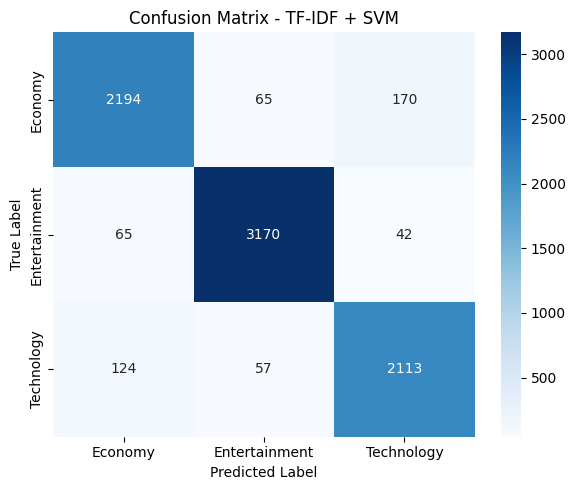

In [70]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Matrix - TF-IDF + SVM"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

## Confussion Matrix

In [71]:
print("\n=== Classification Report ===\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)


=== Classification Report ===

               precision    recall  f1-score   support

      Economy       0.92      0.90      0.91      2429
Entertainment       0.96      0.97      0.97      3277
   Technology       0.91      0.92      0.91      2294

     accuracy                           0.93      8000
    macro avg       0.93      0.93      0.93      8000
 weighted avg       0.93      0.93      0.93      8000



## Overall

In [72]:
acc = accuracy_score(
    y_test,
    y_pred
)

prec = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

rec = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("\n=== TF-IDF + Naive Bayes ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")


=== TF-IDF + Naive Bayes ===
Accuracy : 0.9346
Precision: 0.9308
Recall   : 0.9306
F1-Score : 0.9306


In [73]:
result = pd.DataFrame([
    {
        "Train_Size": len(X_train),
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }
])

In [74]:
result

,Train_Size,Accuracy,Precision,Recall,F1-Score
0,32000,0.934625,0.930815,0.930566,0.930648


In [ ]:
os.makedirs("results", exist_ok=True)
RESULT_FILE = "results/training/tfidf_svm_results.csv"

if os.path.exists(RESULT_FILE):
    previous = pd.read_csv(RESULT_FILE)

    result = pd.concat(
        [previous, result],
        ignore_index=True
    )

    # jika train size sama,
    # simpan hasil terbaru

    result = result.drop_duplicates(
        subset=["Train_Size"],
        keep="last"
    )

result = result.sort_values(by="Train_Size")
result.to_csv(RESULT_FILE, index=False)
